# 03. 모델링 및 평가

분류모델을 비교하고 교차검증, 변수 중요도, 임계값과 위험구간을 확인합니다.

> 각 Part는 설정과 입력 데이터를 다시 확인하도록 구성했습니다. 전체 실행과 부분 재실행 모두 가능합니다.

## 1. 모델 학습 및 홀드아웃 평가

### 0. 실행 환경과 모델링 번들 로드

In [1]:
from pathlib import Path
import platform
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import yaml
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC, SVC

warnings.filterwarnings("ignore")


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "config.yaml").exists():
            return candidate
    raise FileNotFoundError("config.yaml을 찾지 못했습니다. 프로젝트 폴더 안에서 실행하세요.")


ROOT = find_project_root()
with (ROOT / "config.yaml").open("r", encoding="utf-8") as file:
    cfg = yaml.safe_load(file)

FIG_DIR = ROOT / cfg["outputs"]["figures_dir"]
METRIC_DIR = ROOT / cfg["outputs"]["metrics_dir"]
MODEL_DIR = ROOT / cfg["outputs"]["models_dir"]
REPORT_DIR = ROOT / cfg["outputs"]["reports_dir"]
for path in [FIG_DIR, METRIC_DIR, MODEL_DIR, REPORT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = int(cfg["modeling"]["random_state"])
RBF_SAMPLE_SIZE = int(cfg["modeling"]["rbf_sample_size"])

bundle_path = MODEL_DIR / "phase3_bundle.pkl"
if not bundle_path.exists():
    raise FileNotFoundError("먼저 01_data_quality_preprocessing.ipynb를 실행하세요.")
bundle = joblib.load(bundle_path)

X_train = bundle["X_train"]
X_valid = bundle["X_valid"]
y_train = bundle["y_train"]
y_valid = bundle["y_valid"]
feature_names = bundle["feature_names"]

print("PROJECT ROOT: .")
print("Python       :", platform.python_version())
print("scikit-learn :", sklearn.__version__)
print("학습 배열    :", X_train.shape, X_train.dtype)
print("검증 배열    :", X_valid.shape, X_valid.dtype)
print("피처 수      :", len(feature_names))

PROJECT ROOT: .
Python       : 3.13.3
scikit-learn : 1.9.0
학습 배열    : (246008, 263) float32
검증 배열    : (61503, 263) float32
피처 수      : 263


### 1. RBF SVM 계산용 층화 표본

In [2]:
X_rbf, _, y_rbf, _ = train_test_split(
    X_train,
    y_train,
    train_size=RBF_SAMPLE_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE,
)
X_rbf = np.ascontiguousarray(X_rbf, dtype="float32")
y_rbf = np.asarray(y_rbf, dtype="int8")

print(f"RBF 학습 표본: {len(y_rbf):,}건")
print(f"전체 학습 부도율 / RBF 표본 부도율: {y_train.mean()*100:.3f}% / {y_rbf.mean()*100:.3f}%")

RBF 학습 표본: 50,000건
전체 학습 부도율 / RBF 표본 부도율: 8.073% / 8.072%


### 2. 모델 정의와 클래스 불균형 대응

In [3]:
models = {
    "Logistic Regression": LogisticRegression(
        penalty=None,
        class_weight="balanced",
        solver="lbfgs",
        max_iter=2000,
        random_state=RANDOM_STATE,
    ),
    "Regularized Logistic (L2)": LogisticRegression(
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        solver="lbfgs",
        max_iter=2000,
        random_state=RANDOM_STATE,
    ),
    "LDA": LinearDiscriminantAnalysis(
        priors=[0.5, 0.5],
        solver="lsqr",
        shrinkage="auto",
    ),
    "LinearSVC": LinearSVC(
        C=1.0,
        class_weight="balanced",
        dual=False,
        max_iter=5000,
        random_state=RANDOM_STATE,
    ),
    "RBF SVM (5만 행)": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        cache_size=2048,
        random_state=RANDOM_STATE,
    ),
}

training_scope = {
    "Logistic Regression": (len(y_train), "전체 학습 데이터", True),
    "Regularized Logistic (L2)": (len(y_train), "전체 학습 데이터", True),
    "LDA": (len(y_train), "전체 학습 데이터", True),
    "LinearSVC": (len(y_train), "전체 학습 데이터", True),
    "RBF SVM (5만 행)": (len(y_rbf), "층화 5만 건 계산 제약", False),
}

for name, model in models.items():
    print(f"{name:30s} | {model.__class__.__name__}")

Logistic Regression            | LogisticRegression
Regularized Logistic (L2)      | LogisticRegression
LDA                            | LinearDiscriminantAnalysis
LinearSVC                      | LinearSVC
RBF SVM (5만 행)                 | SVC


### 3. 모델 학습

In [4]:
fit_times = {}
for name, model in models.items():
    start = time.perf_counter()
    if name == "RBF SVM (5만 행)":
        model.fit(X_rbf, y_rbf)
    else:
        model.fit(X_train, y_train)
    fit_times[name] = time.perf_counter() - start
    print(f"{name:30s}: {fit_times[name]:8.2f}초")

print(f"총 학습 시간: {sum(fit_times.values()):.2f}초")

Logistic Regression           :     3.33초


Regularized Logistic (L2)     :     3.55초


LDA                           :     1.15초


LinearSVC                     :   168.44초


RBF SVM (5만 행)                :   469.55초
총 학습 시간: 646.03초


### 4. 동일한 검증 데이터에서 성능 평가

In [5]:
result_rows = []
y_scores = {}
y_predictions = {}

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        score = model.predict_proba(X_valid)[:, 1]
    else:
        score = model.decision_function(X_valid)
    prediction = model.predict(X_valid)

    y_scores[name] = score
    y_predictions[name] = prediction
    train_rows, scope, directly_comparable = training_scope[name]
    result_rows.append(
        {
            "model": name,
            "training_rows": train_rows,
            "training_scope": scope,
            "full_train_comparable": directly_comparable,
            "ROC-AUC": roc_auc_score(y_valid, score),
            "PR-AUC": average_precision_score(y_valid, score),
            "Recall": recall_score(y_valid, prediction),
            "Precision": precision_score(y_valid, prediction, zero_division=0),
            "F1": f1_score(y_valid, prediction, zero_division=0),
            "Fit time(s)": fit_times[name],
        }
    )

results_df = pd.DataFrame(result_rows)
metric_columns = ["ROC-AUC", "PR-AUC", "Recall", "Precision", "F1", "Fit time(s)"]
results_df[metric_columns] = results_df[metric_columns].round(4)
results_df.to_csv(
    METRIC_DIR / "model_holdout_performance.csv", index=False, encoding="utf-8-sig"
)

print(results_df.to_string(index=False))
print("\nRBF SVM은 학습 표본 수가 달라 전체 학습 모델과의 직접 비교에 제한이 있습니다.")

                    model  training_rows training_scope  full_train_comparable  ROC-AUC  PR-AUC  Recall  Precision     F1  Fit time(s)
      Logistic Regression         246008      전체 학습 데이터                   True   0.7504  0.2325  0.6812     0.1609 0.2603       3.3311
Regularized Logistic (L2)         246008      전체 학습 데이터                   True   0.7504  0.2324  0.6812     0.1609 0.2603       3.5486
                      LDA         246008      전체 학습 데이터                   True   0.7495  0.2327  0.6767     0.1602 0.2591       1.1538
                LinearSVC         246008      전체 학습 데이터                   True   0.7502  0.2338  0.6792     0.1607 0.2599     168.4447
           RBF SVM (5만 행)          50000  층화 5만 건 계산 제약                  False   0.7315  0.2067  0.5867     0.1732 0.2674     469.5489

RBF SVM은 학습 표본 수가 달라 전체 학습 모델과의 직접 비교에 제한이 있습니다.


### 5. ROC·PR 곡선과 혼동행렬

In [ ]:
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
display_names = {"RBF SVM (5만 행)": "RBF SVM (50k rows)"}

fig, ax = plt.subplots(figsize=(8, 7))
for (name, score), color in zip(y_scores.items(), colors):
    fpr, tpr, _ = roc_curve(y_valid, score)
    auc = roc_auc_score(y_valid, score)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{display_names.get(name, name)}  AUC={auc:.4f}")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random (AUC=0.5)")
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="False Positive Rate", ylabel="True Positive Rate")
ax.set_title("ROC Curves — Five Models")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "model_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 7))
baseline = y_valid.mean()
for (name, score), color in zip(y_scores.items(), colors):
    precision, recall, _ = precision_recall_curve(y_valid, score)
    ap = average_precision_score(y_valid, score)
    ax.plot(recall, precision, color=color, lw=2, label=f"{display_names.get(name, name)}  AP={ap:.4f}")
ax.axhline(baseline, color="black", ls="--", lw=1, alpha=0.6, label=f"Baseline {baseline:.4f}")
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Recall", ylabel="Precision")
ax.set_title("Precision–Recall Curves — Five Models")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "model_precision_recall_curves.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
for ax, (name, prediction) in zip(axes, y_predictions.items()):
    matrix = confusion_matrix(y_valid, prediction)
    normalized = matrix / matrix.sum(axis=1, keepdims=True)
    ax.imshow(normalized, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks([0, 1], ["Pred 0", "Pred 1"])
    ax.set_yticks([0, 1], ["Actual 0", "Actual 1"])
    row = results_df.set_index("model").loc[name]
    ax.set_title(f"{display_names.get(name, name)}\nRecall={row['Recall']:.3f} | Precision={row['Precision']:.3f}", fontsize=9)
    for i in range(2):
        for j in range(2):
            color = "white" if normalized[i, j] > 0.5 else "black"
            ax.text(j, i, f"{matrix[i,j]:,}\n({normalized[i,j]*100:.1f}%)", ha="center", va="center", color=color)
fig.suptitle("Confusion Matrices at Each Model's Default Decision Rule", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "model_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

### 6. 모델과 예측 점수 저장

In [7]:
phase4_bundle = {
    "models": models,
    "results_df": results_df,
    "y_scores": y_scores,
    "y_predictions": y_predictions,
    "y_valid": y_valid,
    "fit_times": fit_times,
    "training_scope": training_scope,
    "feature_names": feature_names,
    "versions": {
        "python": platform.python_version(),
        "scikit_learn": sklearn.__version__,
    },
}
model_path = MODEL_DIR / "phase4a_bundle.pkl"
joblib.dump(phase4_bundle, model_path, compress=3)

best_auc_row = results_df.loc[results_df["ROC-AUC"].idxmax()]
report = f'''# Five-Model Holdout Summary

- 검증 데이터: {len(y_valid):,}건
- 최고 ROC-AUC: {best_auc_row['model']}, {best_auc_row['ROC-AUC']:.4f}
- PR-AUC 기준선: {y_valid.mean():.4f}
- 클래스 불균형 대응: balanced class weight 또는 동일 사전확률

RBF SVM은 계산 제약으로 층화 5만 건에서 학습했으므로 전체 학습 데이터를 사용한 네 모델과 직접 동등 비교하지 않습니다.
클래스 가중치를 사용한 확률 출력은 절대 부도확률보다 상대적 위험 점수로 해석합니다.
'''
report = "\n".join(line.strip() for line in report.strip().splitlines()) + "\n"
(REPORT_DIR / "model_comparison_summary.md").write_text(report, encoding="utf-8")

print("저장:", model_path.relative_to(ROOT))
print(f"모델 번들 크기: {model_path.stat().st_size / 1024**2:.1f} MB (Git 제외)")
print("저장:", (REPORT_DIR / "model_comparison_summary.md").relative_to(ROOT))

저장: outputs\models\phase4a_bundle.pkl
모델 번들 크기: 11.0 MB (Git 제외)
저장: outputs\reports\model_comparison_summary.md


## 2. 검증 및 결과 해석

### 0. 실행 환경과 이전 단계 결과 로드

In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split

warnings.filterwarnings("ignore")


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "config.yaml").exists():
            return candidate
    raise FileNotFoundError("config.yaml을 찾지 못했습니다. 프로젝트 폴더 안에서 실행하세요.")


ROOT = find_project_root()
with (ROOT / "config.yaml").open("r", encoding="utf-8") as file:
    cfg = yaml.safe_load(file)

FIG_DIR = ROOT / cfg["outputs"]["figures_dir"]
METRIC_DIR = ROOT / cfg["outputs"]["metrics_dir"]
MODEL_DIR = ROOT / cfg["outputs"]["models_dir"]
REPORT_DIR = ROOT / cfg["outputs"]["reports_dir"]
for path in [FIG_DIR, METRIC_DIR, REPORT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = int(cfg["modeling"]["random_state"])
CV_FOLDS = int(cfg["modeling"]["cv_folds"])

phase3 = joblib.load(MODEL_DIR / "phase3_bundle.pkl")
phase4 = joblib.load(MODEL_DIR / "phase4a_bundle.pkl")

X_train = phase3["X_train"]
X_valid = phase3["X_valid"]
y_train = phase3["y_train"]
y_valid = phase3["y_valid"]
feature_names = phase3["feature_names"]
feature_std = phase3["transformed_feature_std"]
numeric_count = len(phase3["numeric_columns"])
models = phase4["models"]
y_scores = phase4["y_scores"]
holdout_results = phase4["results_df"]

print("PROJECT ROOT: .")
print("학습/검증:", X_train.shape, X_valid.shape)
print("모델:", list(models))

PROJECT ROOT: .
학습/검증: (246008, 263) (61503, 263)
모델: ['Logistic Regression', 'Regularized Logistic (L2)', 'LDA', 'LinearSVC', 'RBF SVM (5만 행)']


### 1. 5-Fold 교차검증

전체 데이터에서 반복 학습이 가능한 Logistic, L2 Logistic, LDA 세 모델을 검증합니다. LinearSVC와 RBF SVM은 실행시간이 매우 길어 동일한 반복 교차검증 대상에서 제외하며, 이 제한을 결과에 명시합니다.

                    model  ROC_AUC_mean  ROC_AUC_std  PR_AUC_mean  PR_AUC_std
                      LDA        0.7476       0.0027       0.2248      0.0059
      Logistic Regression        0.7481       0.0029       0.2243      0.0059
Regularized Logistic (L2)        0.7481       0.0030       0.2244      0.0060


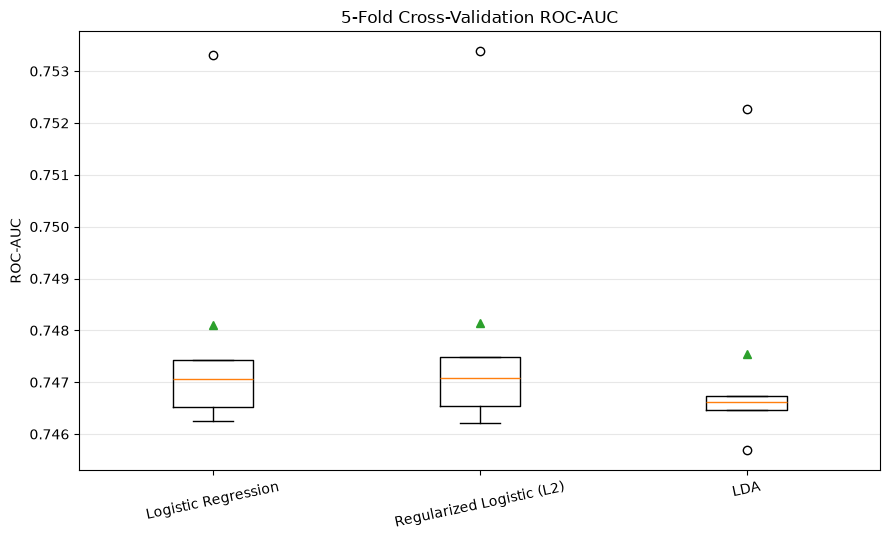

In [2]:
cv_models = {
    name: models[name]
    for name in ["Logistic Regression", "Regularized Logistic (L2)", "LDA"]
}
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision"}

fold_rows = []
for name, model in cv_models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )
    for fold in range(CV_FOLDS):
        fold_rows.append(
            {
                "model": name,
                "fold": fold + 1,
                "ROC-AUC": scores["test_roc_auc"][fold],
                "PR-AUC": scores["test_pr_auc"][fold],
            }
        )

cv_folds_df = pd.DataFrame(fold_rows)
cv_summary = (
    cv_folds_df.groupby("model")
    .agg(
        ROC_AUC_mean=("ROC-AUC", "mean"),
        ROC_AUC_std=("ROC-AUC", "std"),
        PR_AUC_mean=("PR-AUC", "mean"),
        PR_AUC_std=("PR-AUC", "std"),
    )
    .reset_index()
)
cv_folds_df.to_csv(METRIC_DIR / "cross_validation_fold_scores.csv", index=False, encoding="utf-8-sig")
cv_summary.to_csv(METRIC_DIR / "cross_validation_summary.csv", index=False, encoding="utf-8-sig")

print(cv_summary.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5.5))
names = list(cv_models)
values = [cv_folds_df.loc[cv_folds_df["model"].eq(name), "ROC-AUC"] for name in names]
ax.boxplot(values, tick_labels=names, showmeans=True)
ax.set_ylabel("ROC-AUC")
ax.set_title("5-Fold Cross-Validation ROC-AUC")
ax.tick_params(axis="x", rotation=12)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "cross_validation_roc_auc.png", dpi=150, bbox_inches="tight")
plt.show()

### 2. L2 Logistic 계수 중요도 기준 교정

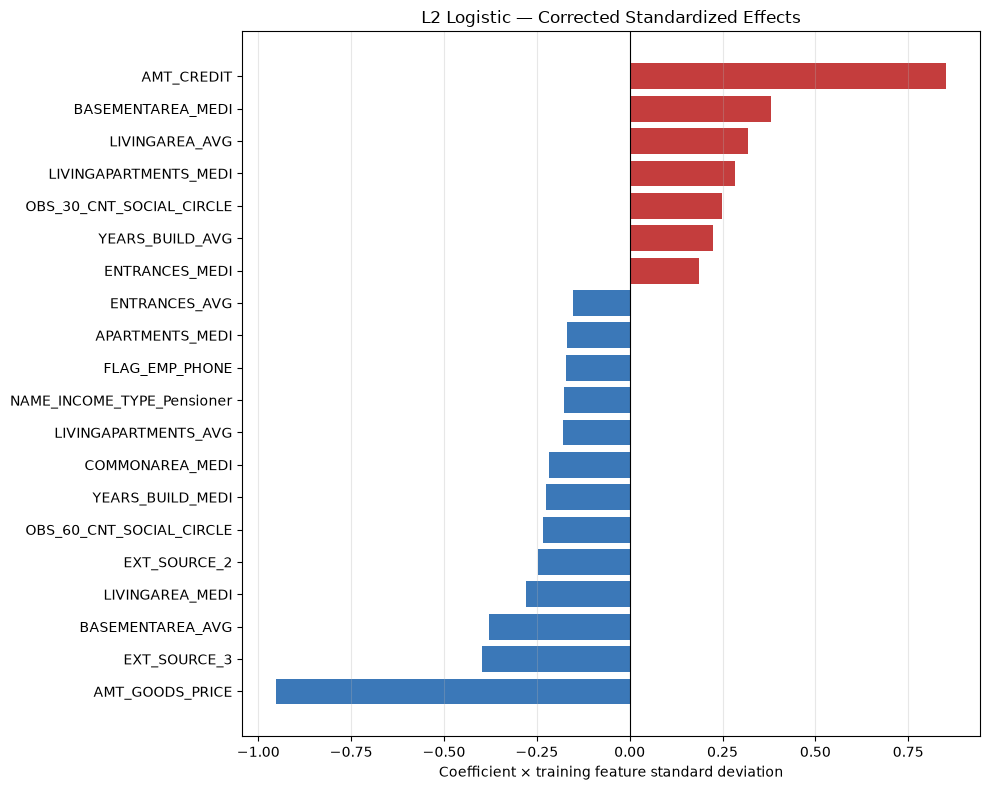

 rank  raw_abs_rank                    feature      feature_type  raw_coefficient  train_feature_std  standardized_effect
    1             1            AMT_GOODS_PRICE    numeric_scaled         -0.95291            0.99995             -0.95286
    2             2                 AMT_CREDIT    numeric_scaled          0.85297            0.99998              0.85295
    3            11               EXT_SOURCE_3    numeric_scaled         -0.39728            1.00017             -0.39735
    4            12          BASEMENTAREA_MEDI    numeric_scaled          0.37987            1.00077              0.38017
    5            13           BASEMENTAREA_AVG    numeric_scaled         -0.37870            1.00084             -0.37902
    6            16             LIVINGAREA_AVG    numeric_scaled          0.31945            1.00028              0.31953
    7            24      LIVINGAPARTMENTS_MEDI    numeric_scaled          0.28518            0.99890              0.28487
    8            27     

In [3]:
l2_model = models["Regularized Logistic (L2)"]
raw_coefficient = l2_model.coef_[0]
standardized_effect = raw_coefficient * feature_std
raw_abs_rank = pd.Series(np.abs(raw_coefficient)).rank(method="min", ascending=False).astype(int).to_numpy()

coefficient_importance = pd.DataFrame(
    {
        "feature": feature_names,
        "feature_type": [
            "numeric_scaled" if index < numeric_count else "categorical_dummy"
            for index in range(len(feature_names))
        ],
        "raw_coefficient": raw_coefficient,
        "raw_abs_rank": raw_abs_rank,
        "train_feature_std": feature_std,
        "standardized_effect": standardized_effect,
        "abs_standardized_effect": np.abs(standardized_effect),
    }
).sort_values("abs_standardized_effect", ascending=False)
coefficient_importance.insert(0, "rank", range(1, len(coefficient_importance) + 1))
coefficient_importance.to_csv(
    METRIC_DIR / "logistic_standardized_effects.csv",
    index=False,
    encoding="utf-8-sig",
)

top_coefficient = coefficient_importance.head(20).sort_values("standardized_effect")
colors = ["#c43d3d" if value > 0 else "#3b78b8" for value in top_coefficient["standardized_effect"]]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_coefficient["feature"], top_coefficient["standardized_effect"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Coefficient × training feature standard deviation")
ax.set_title("L2 Logistic — Corrected Standardized Effects")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "logistic_standardized_effects.png", dpi=150, bbox_inches="tight")
plt.show()

print(coefficient_importance.head(20)[
    ["rank", "raw_abs_rank", "feature", "feature_type", "raw_coefficient", "train_feature_std", "standardized_effect"]
].round(5).to_string(index=False))

### 3. 검증 데이터 permutation importance

각 피처를 무작위로 섞었을 때 ROC-AUC가 얼마나 감소하는지 측정합니다. 계산량을 통제하기 위해 검증 데이터에서 부도율을 보존한 20,000건을 사용하고 3회 반복합니다. 이는 계수 크기와 다른, 검증 성능 기반 중요도입니다.

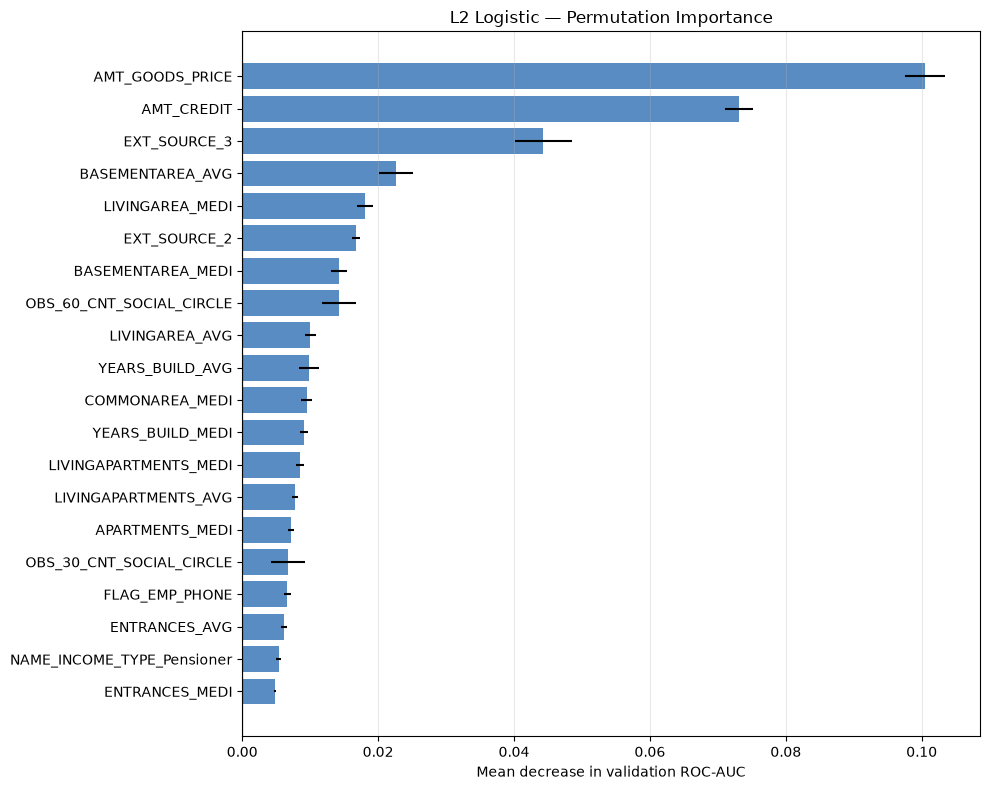

 rank                    feature  importance_mean  importance_std
    1            AMT_GOODS_PRICE         0.100488        0.002921
    2                 AMT_CREDIT         0.073064        0.002074
    3               EXT_SOURCE_3         0.044336        0.004252
    4           BASEMENTAREA_AVG         0.022666        0.002492
    5            LIVINGAREA_MEDI         0.018070        0.001192
    6               EXT_SOURCE_2         0.016700        0.000581
    7          BASEMENTAREA_MEDI         0.014228        0.001125
    8   OBS_60_CNT_SOCIAL_CIRCLE         0.014190        0.002488
    9             LIVINGAREA_AVG         0.010005        0.000784
   10            YEARS_BUILD_AVG         0.009817        0.001481
   11            COMMONAREA_MEDI         0.009466        0.000763
   12           YEARS_BUILD_MEDI         0.009092        0.000590
   13      LIVINGAPARTMENTS_MEDI         0.008528        0.000582
   14       LIVINGAPARTMENTS_AVG         0.007728        0.000451
   15     

In [4]:
X_perm, _, y_perm, _ = train_test_split(
    X_valid,
    y_valid,
    train_size=20_000,
    stratify=y_valid,
    random_state=RANDOM_STATE,
)
permutation = permutation_importance(
    l2_model,
    X_perm,
    y_perm,
    scoring="roc_auc",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
permutation_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance_mean": permutation.importances_mean,
        "importance_std": permutation.importances_std,
    }
).sort_values("importance_mean", ascending=False)
permutation_df.insert(0, "rank", range(1, len(permutation_df) + 1))
permutation_df.to_csv(
    METRIC_DIR / "logistic_permutation_importance.csv", index=False, encoding="utf-8-sig"
)

top_permutation = permutation_df.head(20).sort_values("importance_mean")
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    top_permutation["feature"],
    top_permutation["importance_mean"],
    xerr=top_permutation["importance_std"],
    color="#3b78b8",
    alpha=0.85,
)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Mean decrease in validation ROC-AUC")
ax.set_title("L2 Logistic — Permutation Importance")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "logistic_permutation_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(permutation_df.head(20).round(6).to_string(index=False))

### 4. L2 Logistic 임계값 시나리오

     scenario  threshold  Recall  Precision     F1
        기본 임계       0.50  0.6812     0.1609 0.2603
       F1 최대화       0.66  0.4268     0.2320 0.3006
Recall 80% 이상       0.41  0.8000     0.1348 0.2308


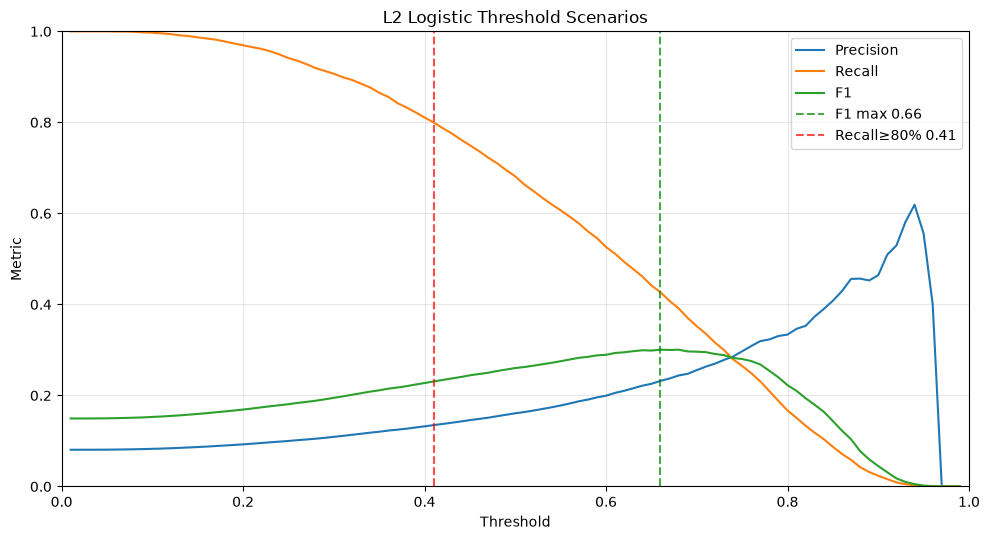

In [5]:
l2_score = y_scores["Regularized Logistic (L2)"]
thresholds = np.linspace(0.01, 0.99, 99)
threshold_rows = []
for threshold in thresholds:
    prediction = (l2_score >= threshold).astype("int8")
    threshold_rows.append(
        {
            "threshold": threshold,
            "Recall": recall_score(y_valid, prediction),
            "Precision": precision_score(y_valid, prediction, zero_division=0),
            "F1": f1_score(y_valid, prediction, zero_division=0),
        }
    )
threshold_grid = pd.DataFrame(threshold_rows)

default_row = threshold_grid.iloc[(threshold_grid["threshold"] - 0.5).abs().argmin()]
f1_row = threshold_grid.loc[threshold_grid["F1"].idxmax()]
recall80_candidates = threshold_grid[threshold_grid["Recall"] >= 0.80]
recall80_row = recall80_candidates.iloc[-1]

threshold_summary = pd.DataFrame(
    [
        {
            "scenario": "기본 임계",
            "threshold": default_row["threshold"],
            "Recall": default_row["Recall"],
            "Precision": default_row["Precision"],
            "F1": default_row["F1"],
        },
        {
            "scenario": "F1 최대화",
            "threshold": f1_row["threshold"],
            "Recall": f1_row["Recall"],
            "Precision": f1_row["Precision"],
            "F1": f1_row["F1"],
        },
        {
            "scenario": "Recall 80% 이상",
            "threshold": recall80_row["threshold"],
            "Recall": recall80_row["Recall"],
            "Precision": recall80_row["Precision"],
            "F1": recall80_row["F1"],
        },
    ]
)
threshold_summary.to_csv(
    METRIC_DIR / "threshold_scenarios.csv", index=False, encoding="utf-8-sig"
)
print(threshold_summary.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(threshold_grid["threshold"], threshold_grid["Precision"], label="Precision")
ax.plot(threshold_grid["threshold"], threshold_grid["Recall"], label="Recall")
ax.plot(threshold_grid["threshold"], threshold_grid["F1"], label="F1")
ax.axvline(f1_row["threshold"], color="green", ls="--", alpha=0.7, label=f"F1 max {f1_row['threshold']:.2f}")
ax.axvline(recall80_row["threshold"], color="red", ls="--", alpha=0.7, label=f"Recall≥80% {recall80_row['threshold']:.2f}")
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Threshold", ylabel="Metric")
ax.set_title("L2 Logistic Threshold Scenarios")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "logistic_threshold_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

### 5. 위험 10분위와 Lift

 decile    n  default_count  avg_risk_score_percent  actual_default_rate_percent   lift
      1 6151             81               11.867200                       1.3169 0.1631
      2 6150            129               19.631500                       2.0976 0.2598
      3 6150            205               25.546600                       3.3333 0.4129
      4 6150            193               31.150400                       3.1382 0.3887
      5 6151            313               36.751099                       5.0886 0.6303
      6 6150            390               42.810799                       6.3415 0.7855
      7 6150            507               49.467602                       8.2439 1.0212
      8 6150            612               56.993599                       9.9512 1.2327
      9 6150            906               65.952103                      14.7317 1.8249
     10 6151           1629               79.218300                      26.4835 3.2806


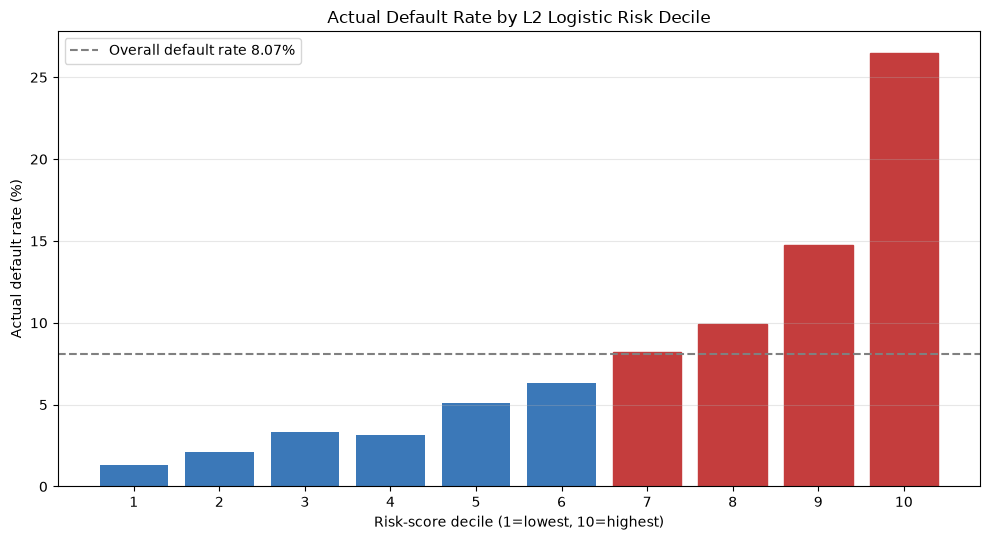

In [6]:
risk = pd.DataFrame({"score": l2_score, "target": y_valid})
risk["decile"] = pd.qcut(risk["score"], q=10, labels=False, duplicates="drop") + 1
risk_summary = (
    risk.groupby("decile", observed=True)
    .agg(
        n=("target", "size"),
        default_count=("target", "sum"),
        avg_risk_score=("score", "mean"),
        actual_default_rate=("target", "mean"),
    )
    .reset_index()
)
baseline = y_valid.mean()
risk_summary["lift"] = risk_summary["actual_default_rate"] / baseline
risk_summary["avg_risk_score_percent"] = risk_summary["avg_risk_score"] * 100
risk_summary["actual_default_rate_percent"] = risk_summary["actual_default_rate"] * 100
risk_output = risk_summary[
    [
        "decile", "n", "default_count", "avg_risk_score_percent",
        "actual_default_rate_percent", "lift",
    ]
]
risk_output.to_csv(
    METRIC_DIR / "risk_decile_summary.csv", index=False, encoding="utf-8-sig"
)
print(risk_output.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(risk_output["decile"], risk_output["actual_default_rate_percent"], color="#3b78b8")
for bar, value in zip(bars, risk_output["lift"]):
    if value > 1:
        bar.set_color("#c43d3d")
ax.axhline(baseline * 100, color="gray", ls="--", label=f"Overall default rate {baseline*100:.2f}%")
ax.set_xticks(risk_output["decile"])
ax.set_xlabel("Risk-score decile (1=lowest, 10=highest)")
ax.set_ylabel("Actual default rate (%)")
ax.set_title("Actual Default Rate by L2 Logistic Risk Decile")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "risk_decile_default_rate.png", dpi=150, bbox_inches="tight")
plt.show()

### 6. 검증 요약 보고서

In [7]:
best_holdout = holdout_results.loc[holdout_results["ROC-AUC"].idxmax()]
l2_holdout = holdout_results.set_index("model").loc["Regularized Logistic (L2)"]
top_decile = risk_output.loc[risk_output["decile"].idxmax()]
top_standardized = coefficient_importance.iloc[0]
top_permutation_row = permutation_df.iloc[0]
realtor_row = coefficient_importance.loc[
    coefficient_importance["feature"].eq("ORGANIZATION_TYPE_Realtor")
].iloc[0]
credit_index = feature_names.index("AMT_CREDIT")
goods_index = feature_names.index("AMT_GOODS_PRICE")
credit_goods_correlation = np.corrcoef(
    X_train[:, credit_index], X_train[:, goods_index]
)[0, 1]

report = f'''# Model Validation Summary

## 모델 성능

- 최고 홀드아웃 ROC-AUC: {best_holdout['model']}, {best_holdout['ROC-AUC']:.4f}
- L2 Logistic ROC-AUC: {l2_holdout['ROC-AUC']:.4f}
- L2 Logistic PR-AUC: {l2_holdout['PR-AUC']:.4f}
- 검증 데이터 부도율(PR-AUC 기준선): {y_valid.mean():.4f}

## 위험구간

- 상위 위험 10% 실제 부도율: {top_decile['actual_default_rate_percent']:.2f}%
- 상위 위험 10% Lift: {top_decile['lift']:.2f}

## 변수 중요도 교정

기존 절대계수 순위는 표준화된 수치형 변수와 0/1 더미 변수를 직접 비교해 단위가 통일되지 않았습니다.
교정 후 표준화 효과 1위는 {top_standardized['feature']}이고,
검증 permutation importance 1위는 {top_permutation_row['feature']}입니다.
두 결과는 각각 계수 효과 크기와 검증 성능 기여도를 의미하며 동일한 중요도로 해석하지 않습니다.
ORGANIZATION_TYPE_Realtor는 원계수 절댓값 기준 {int(realtor_row['raw_abs_rank'])}위였지만
표준화 효과 기준 {int(realtor_row['rank'])}위로 이동했습니다.

AMT_CREDIT과 AMT_GOODS_PRICE의 학습 데이터 상관은 {credit_goods_correlation:.4f}입니다.
두 변수처럼 강하게 연관된 피처의 개별 계수 부호와 permutation 중요도는 불안정할 수 있으므로
공동 신용금액 신호로 제한해 해석하며 인과효과로 해석하지 않습니다.

## 선택과 한계

L2 Logistic은 최고 모델과 사실상 동일한 순위 성능, 빠른 학습, 규제와 해석 가능성의 균형 때문에 주 모델로 사용합니다.
클래스 가중치가 적용된 점수는 보정된 절대 부도확률이 아니라 상대적 위험 순위로 해석합니다.
RBF SVM은 5만 건에서만 학습했으므로 전체 학습 모델과 직접 동등 비교하지 않습니다.
'''
report = "\n".join(line.strip() for line in report.strip().splitlines()) + "\n"
(REPORT_DIR / "model_validation_summary.md").write_text(report, encoding="utf-8")

print(report)
print("Phase 4 검증 완료")

# Model Validation Summary

## 모델 성능

- 최고 홀드아웃 ROC-AUC: Logistic Regression, 0.7504
- L2 Logistic ROC-AUC: 0.7504
- L2 Logistic PR-AUC: 0.2324
- 검증 데이터 부도율(PR-AUC 기준선): 0.0807

## 위험구간

- 상위 위험 10% 실제 부도율: 26.48%
- 상위 위험 10% Lift: 3.28

## 변수 중요도 교정

기존 절대계수 순위는 표준화된 수치형 변수와 0/1 더미 변수를 직접 비교해 단위가 통일되지 않았습니다.
교정 후 표준화 효과 1위는 AMT_GOODS_PRICE이고,
검증 permutation importance 1위는 AMT_GOODS_PRICE입니다.
두 결과는 각각 계수 효과 크기와 검증 성능 기여도를 의미하며 동일한 중요도로 해석하지 않습니다.
ORGANIZATION_TYPE_Realtor는 원계수 절댓값 기준 3위였지만
표준화 효과 기준 93위로 이동했습니다.

AMT_CREDIT과 AMT_GOODS_PRICE의 학습 데이터 상관은 0.9868입니다.
두 변수처럼 강하게 연관된 피처의 개별 계수 부호와 permutation 중요도는 불안정할 수 있으므로
공동 신용금액 신호로 제한해 해석하며 인과효과로 해석하지 않습니다.

## 선택과 한계

L2 Logistic은 최고 모델과 사실상 동일한 순위 성능, 빠른 학습, 규제와 해석 가능성의 균형 때문에 주 모델로 사용합니다.
클래스 가중치가 적용된 점수는 보정된 절대 부도확률이 아니라 상대적 위험 순위로 해석합니다.
RBF SVM은 5만 건에서만 학습했으므로 전체 학습 모델과 직접 동등 비교하지 않습니다.

Phase 4 검증 완료
